In [1]:
from dataset_loaders import build_data_loaders
from utils.checkpoints import load_ae_from_path, load_from_wandb
from pathlib import Path
import torch

from utils.config import DatasetConfig
from utils.visualisation import show

In [2]:
ae_path = Path("../checkpoints/autoencoder/flowers.pt")
ae = load_ae_from_path(ae_path)


In [3]:
dataset_cfg = DatasetConfig(
    name="flowers102",
    channels=3,
    height=128,
    width=128,
    num_classes=102,
    num_workers=1
)

dataloader, test_loader = build_data_loaders(dataset_cfg, batch_size=64)


In [4]:
images, labels = next(iter(dataloader))

with torch.no_grad():
    recon, mu, logvar = ae(images)


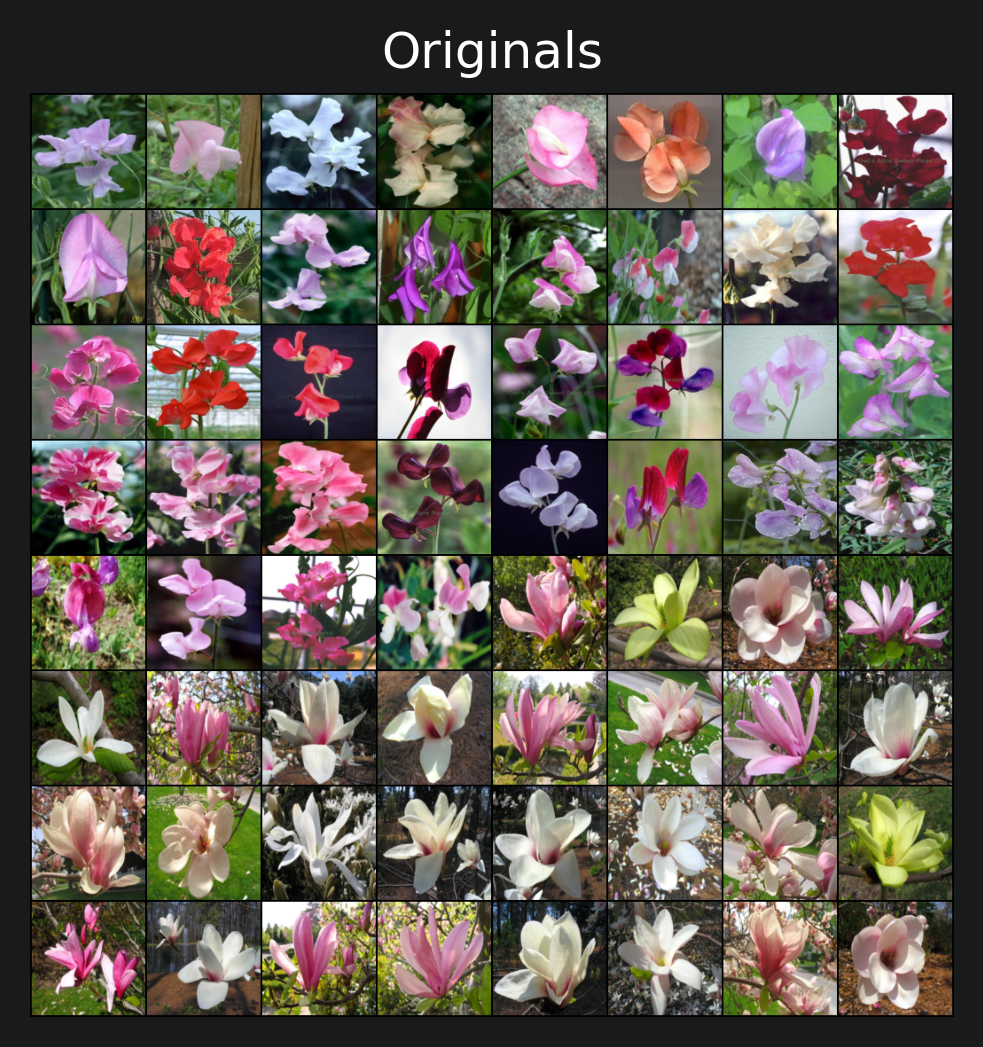

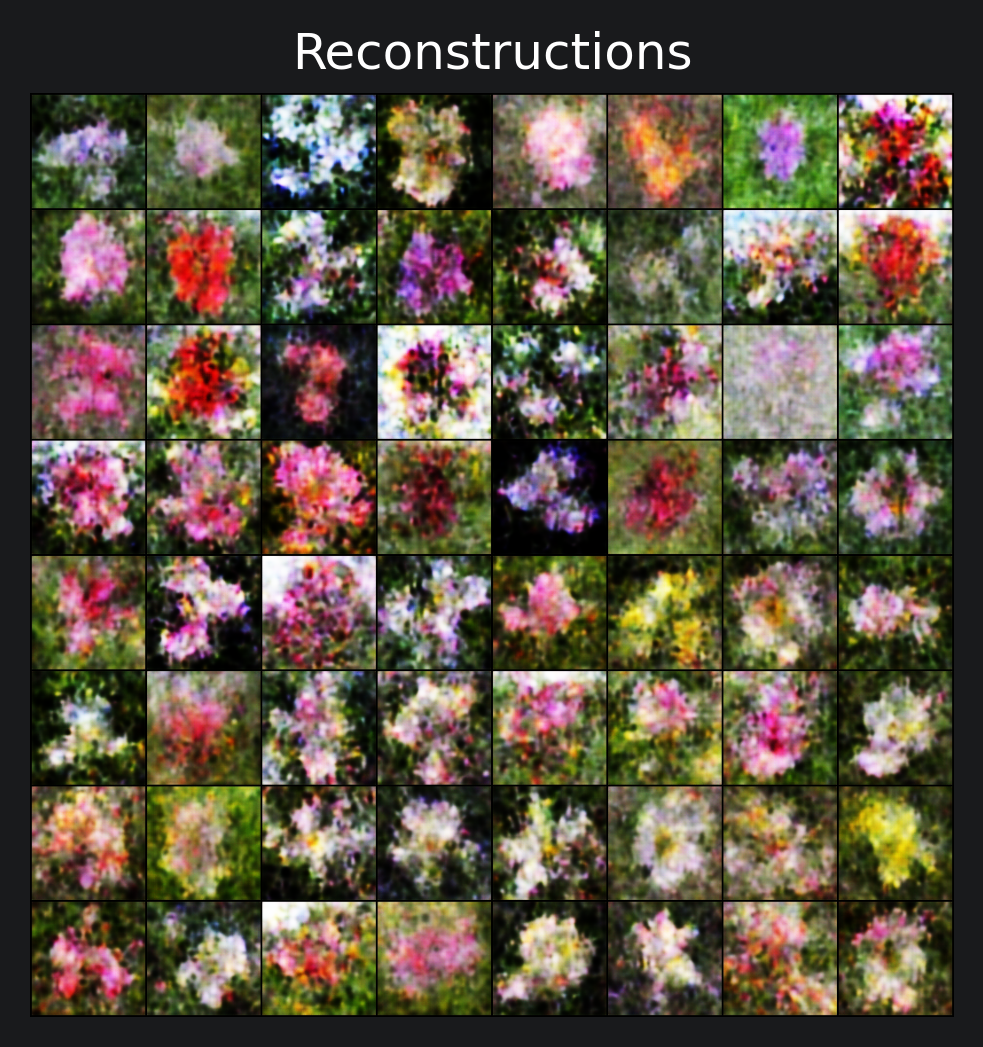

In [6]:
show(images, "Originals")
show(recon, "Reconstructions")

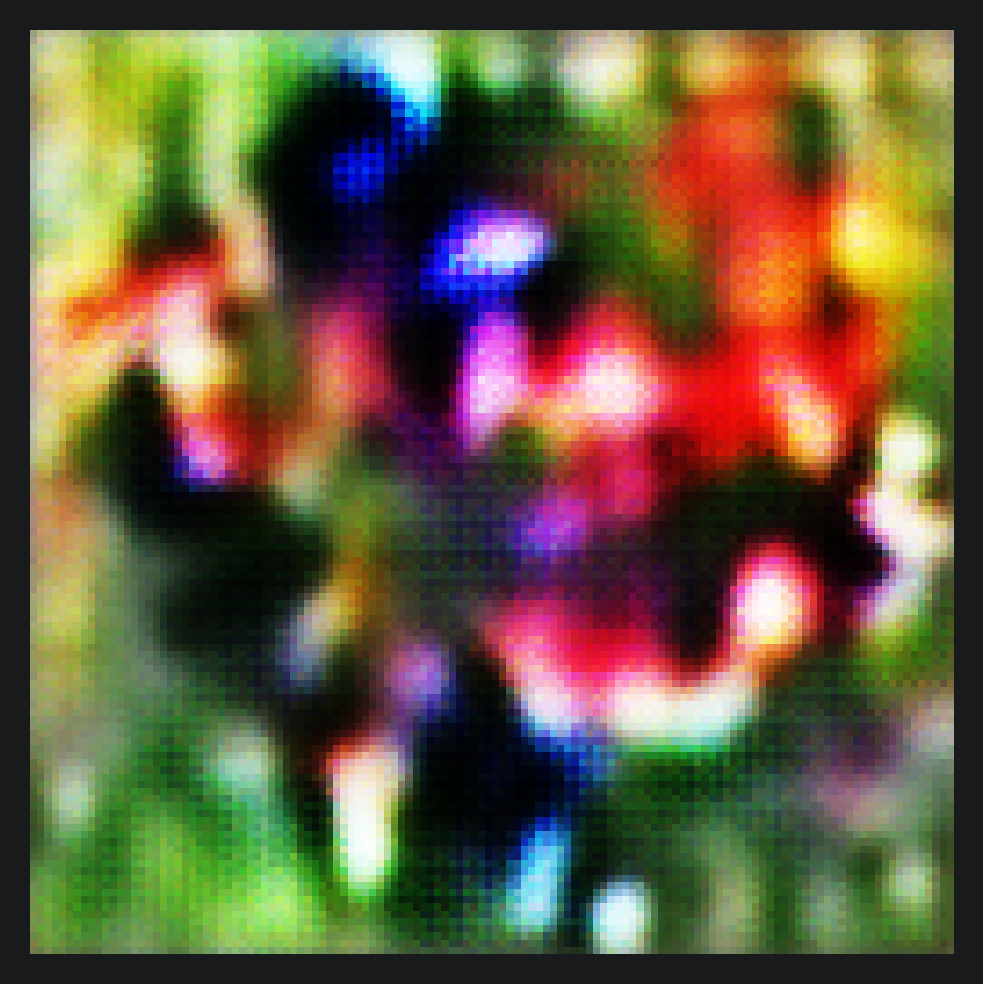

In [7]:
z_zero = torch.rand(1, ae.latent_dim)

with torch.no_grad():
    img_zero = ae.decode(z_zero)

show(img_zero)

In [8]:
latents = ae.encode(images)
print(latents.mean(dim=1))
print(latents.std(dim=1))
print(latents.min(), latents.max())

tensor([-20.3740,  -7.9550,  34.2392,  -1.6147,  43.1392, -42.8660,  43.0279,
         73.2489,  36.6384, -50.6195,  52.3620,  10.5947,  15.4184,   1.7333,
         25.2156,   2.7077,  14.2578, -66.4270, -14.6077, -49.3539, -35.7818,
        -20.0683,  34.8128,  23.9863,  23.3260, -30.8729,  51.8942,   7.4194,
        123.4039,  -5.7878,  31.6576,  21.5717, -19.9063,  52.2069,  37.9041,
         26.1344,  24.3318, -10.4907,   7.0495, -15.9139,  27.7279,  19.2265,
         12.1682,  43.7637,  12.0360,  -7.8985,  34.6143,  22.0100,  29.7449,
         -0.6136,  53.4957,  10.7801,   8.7987,  16.6072,  -3.6897,   7.3378,
         38.8609,   2.5021,  -6.7185,   3.7476,  49.0607,  79.0707,  28.2411,
         -0.3083], grad_fn=<MeanBackward1>)
tensor([261.6152, 229.2542, 410.9946, 292.1391, 291.8826, 239.5371, 324.6114,
        339.9648, 268.7115, 239.4797, 340.3272, 273.5192, 302.6119, 207.9229,
        364.9746, 320.2119, 245.6327, 280.2518, 258.5136, 511.5773, 311.7437,
        283.6165, 34